In [36]:
#run if not insttaled
#!pip install pymysql
#pip install python-dotenv

In [37]:
import json
import requests # http req
import pandas as pd #data manipulation
from datetime import datetime, timezone #datetime module
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #data visualization
from dotenv import load_dotenv
import os
from pathlib import Path

Get data by api cal

In [ ]:
OPENWEATHER_API_KEY = 'your api key here'
CITY = 'your city here'
info_get = f"http://api.openweathermap.org/geo/1.0/direct?q={CITY}&limit=1&appid={OPENWEATHER_API_KEY}"
info_res = requests.get(info_get)

if info_res.status_code == 200:
    info_data = info_res.json()
    if info_data:
        lat = info_data[0]['lat']
        lon = info_data[0]['lon']
        print(f"City: {CITY}, Latitude: {lat}, Longitude: {lon}")
    else:
        print("No location data found.")
else:
    print("Error:", info_res.status_code)


Error: 401


In [40]:
url = f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&cnt=40&appid={OPENWEATHER_API_KEY}&units=metric" # 240h
data_res = requests.get(url)

NameError: name 'lat' is not defined

In [ ]:
if data_res.status_code == 200:
    forecast = data_res.json()
    json_str = json.dumps(forecast, indent=4)
    print(json_str)
else:
    print("Error:", info_res.status_code)

{
    "cod": "200",
    "message": 0,
    "cnt": 15,
    "list": [
        {
            "dt": 1762041600,
            "main": {
                "temp": 6.9,
                "feels_like": 3.86,
                "temp_min": 6.9,
                "temp_max": 7.49,
                "pressure": 1016,
                "sea_level": 1016,
                "grnd_level": 1015,
                "humidity": 93,
                "temp_kf": -0.59
            },
            "weather": [
                {
                    "id": 802,
                    "main": "Clouds",
                    "description": "scattered clouds",
                    "icon": "03n"
                }
            ],
            "clouds": {
                "all": 33
            },
            "wind": {
                "speed": 4.68,
                "deg": 150,
                "gust": 12.83
            },
            "visibility": 10000,
            "pop": 0,
            "sys": {
                "pod": "n"
            },
           

In [ ]:
#kelvin to celciuis(comment out if you needed)
#here is two code lines to check what temp you getting k or c
# temps = forecast["list"][0]["main"]["temp"]
# print(temps)
#def kel_to_cel(temp):
#    temps = forecast["list"][0]["main"]["temp"]
#    return temps - 273.15


In [ ]:
weather_data = []

for hour in forecast['list']:
    date_time = datetime.fromtimestamp(hour['dt'], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S")
    # From 'main'
    temp = hour["main"]["temp"]
    feels_like = hour["main"]["feels_like"]
    pressure = hour["main"]["pressure"]
    humidity = hour["main"]["humidity"]
    # From 'weather' list
    weather_main = hour["weather"][0]["main"]
    weather_desc = hour["weather"][0]["description"]
    # From 'clouds'
    cloud = hour["clouds"]["all"]
    # From 'wind'
    wind_speed = hour["wind"]["speed"]
    wind_direction = hour["wind"]["deg"]
    # Sunrise and sunset not available in this API, skip or set as None
    sunrise = None
    sunset = None
    # Append as a dictionary
    weather_data.append({
        "datetime": date_time,
        "temp": temp,
        "feels_like": feels_like,
        "pressure": pressure,
        "humidity": humidity,
        "weather_main": weather_main,
        "weather_desc": weather_desc,
        "cloud": cloud,
        "wind_speed": wind_speed,
        "wind_direction": wind_direction,
        "sunrise": sunrise,
        "sunset": sunset
    })
df = pd.DataFrame(weather_data)
df.head(10)

,datetime,temp,feels_like,pressure,humidity,weather_main,weather_desc,cloud,wind_speed,wind_direction,sunrise,sunset
0,2025-11-02 00:00:00,6.90,3.86,1016,93,Clouds,scattered clouds,33,4.68,150,None,None
1,2025-11-02 03:00:00,7.46,4.44,1015,85,Clouds,broken clouds,67,4.93,159,None,None
2,2025-11-02 06:00:00,8.25,5.39,1014,80,Clouds,overcast clouds,100,5.03,164,None,None
3,2025-11-02 09:00:00,8.39,5.78,1013,87,Rain,light rain,100,4.53,165,None,None
4,2025-11-02 12:00:00,8.94,6.69,1012,81,Clouds,overcast clouds,100,4.03,170,None,None
5,2025-11-02 15:00:00,8.13,5.88,1012,85,Clouds,overcast clouds,100,3.66,159,None,None
6,2025-11-02 18:00:00,7.94,5.98,1012,91,Clouds,overcast clouds,100,3.09,163,None,None
7,2025-11-02 21:00:00,7.74,5.83,1011,92,Rain,light rain,100,2.95,168,None,None
8,2025-11-03 00:00:00,7.62,6.50,1011,97,Rain,moderate rain,100,1.91,167,None,None
9,2025-11-03 03:00:00,7.85,7.33,1010,98,Rain,light rain,100,1.39,196,None,None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   datetime        15 non-null     object 
 1   temp            15 non-null     float64
 2   feels_like      15 non-null     float64
 3   pressure        15 non-null     int64  
 4   humidity        15 non-null     int64  
 5   weather_main    15 non-null     object 
 6   weather_desc    15 non-null     object 
 7   cloud           15 non-null     int64  
 8   wind_speed      15 non-null     float64
 9   wind_direction  15 non-null     int64  
 10  sunrise         0 non-null      object 
 11  sunset          0 non-null      object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.5+ KB


In [ ]:
# Convert 'datetime' to pandas datetime
df['datetime'] = pd.to_datetime(df['datetime'])
# Extract day and hour
df['Day'] = df['datetime'].dt.date
df['Hour'] = df['datetime'].dt.hour
# Pivot the table: rows = Day, columns = Hour, values = temp
df_pivot = df.pivot(index='Day', columns='Hour', values='temp')
print(df_pivot)

Hour          0     3     6     9      12    15    18    21
Day                                                        
2025-11-02  6.90  7.46  8.25  8.39   8.94  8.13  7.94  7.74
2025-11-03  7.62  7.85  8.43  9.38  10.67  9.28  8.17   NaN


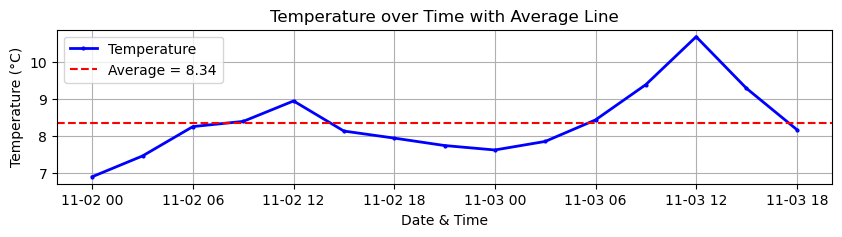

In [ ]:
# Compute average temperature
avg_value = df['temp'].mean()

# Customize grid and figure
plt.figure(figsize=(10, 2))
plt.plot(
    df['datetime'],
    df['temp'],
    color='b',
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=2,
    label='Temperature'
)

# Add average line
plt.axhline(y=avg_value, color='r', linestyle='--', label=f"Average = {avg_value:.2f}")

# Titles and labels
plt.title("Temperature over Time with Average Line")
plt.xlabel('Date & Time')
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

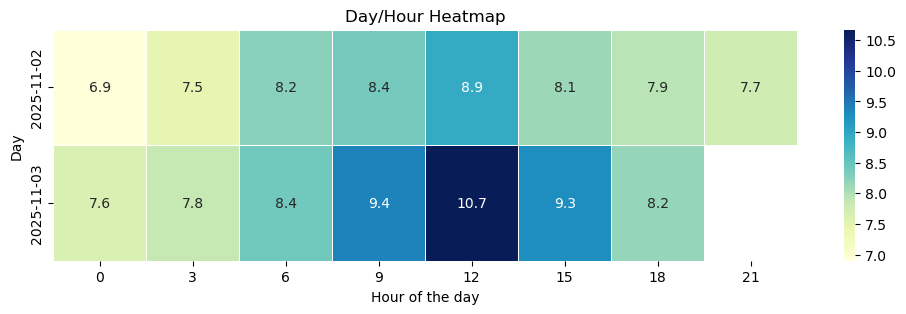

In [ ]:
plt.figure(figsize=(12,3))
sns.heatmap(df_pivot, cmap='YlGnBu', annot=True, fmt='.1f', linewidths=.5)
plt.title('Day/Hour Heatmap')
plt.xlabel('Hour of the day')
plt.ylabel('Day')
plt.show()

In [ ]:
import pymysql
# Use the variables read earlier from the .env cell (MYSQL_HOST, MYSQL_PORT, etc.)
conn = pymysql.connect(
    MYSQL_HOST= 'your sql host here',
    MYSQL_USER='your sql user here',
    MYSQL_PASSWORD='your sql password here',
    MYSQL_DATABASE='your sql database here',
    MYSQL_PORT= 'your sql port here'
)

#Creates a cursor object which allows to execute SQL queries in Python
cursor = conn.cursor()

#creates table in mysql
cursor.execute("""
CREATE TABLE IF NOT EXISTS weather_data (
    datetime DATETIME,
    temp FLOAT,
    feels_like FLOAT,
    pressure INT,
    humidity INT,
    weather_main VARCHAR(50),
    weather_desc VARCHAR(100),
    cloud INT,
    wind_speed FLOAT,
    wind_direction INT,
    sunrise DATETIME,
    sunset DATETIME
)
""")

for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO weather_data (
            datetime, temp, feels_like, pressure, humidity,
            weather_main, weather_desc, cloud, wind_speed,
            wind_direction, sunrise, sunset
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, (
        row['datetime'], row['temp'], row['feels_like'], row['pressure'], row['humidity'],
        row['weather_main'], row['weather_desc'], row['cloud'], row['wind_speed'],
        row['wind_direction'], row['sunrise'], row['sunset']
    ))

conn.commit()
cursor.close()
conn.close()
